# Vector Error Correction Model (VECM) Parameter Estimation With Two Cointegrating Vectors

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import vecm, adf, stats, arima
from lib.plots import comparison, stack, twinx, comparison_stack, curve
from lib.data.impl.stats import OLS

# Config Plot Style
pyplot.style.use(config.glyfish_style)

In [2]:
def adf_test(xt):
    for i in range(len(xt)):
        result, _ = adf.compute_adf_test(xt[i])
        if result.status_vals[1]:
            print("Not Stationary")
        else:
            print("Stationary")

def plot_vecm_simulation(t, xt, title):
    labels = [r"$x_1$", r"$x_2$", r"$x_3$"]   
    comparison(xt, t, labels =labels, title=title, xlabel=r"$t$", lw=1, title_offset=0.05)

def plot_vecm_dff(dxt, title):
    labels = [r"$\Delta x_1$", r"$\Delta x_2$", r"$\Delta x_3$"]   
    stack(dxt, title=title, ylabels=labels, xlabel=r"$t$", lw=1, title_offset=0.05, figsize=(10, 8))

def pacf_acf_plot(t, dxt, nlags, title):
    acf = [stats.compute_acf(t, samp, nlags=nlags) for samp in dxt] 
    pacf = [arima.compute_pacf(samp, nlags=nlags) for samp in dxt]
    data = [[acf[i][1], pacf[i][1]] for i in range(len(dxt))]
    time = [[acf[i][0], pacf[i][0]] for i in range(len(dxt))]
    comparison_stack(data, time, title=title, xlabel=r"Lag", ylim=(-0.4, 1.0), figsize=(10, 8), 
                     labels=[["ACF", "PACF"]], ylabels=[r"$\Delta x_1$", r"$\Delta x_2$", r"$\Delta x_3$"])

## VECM(1) Two Cointegrating Vectors

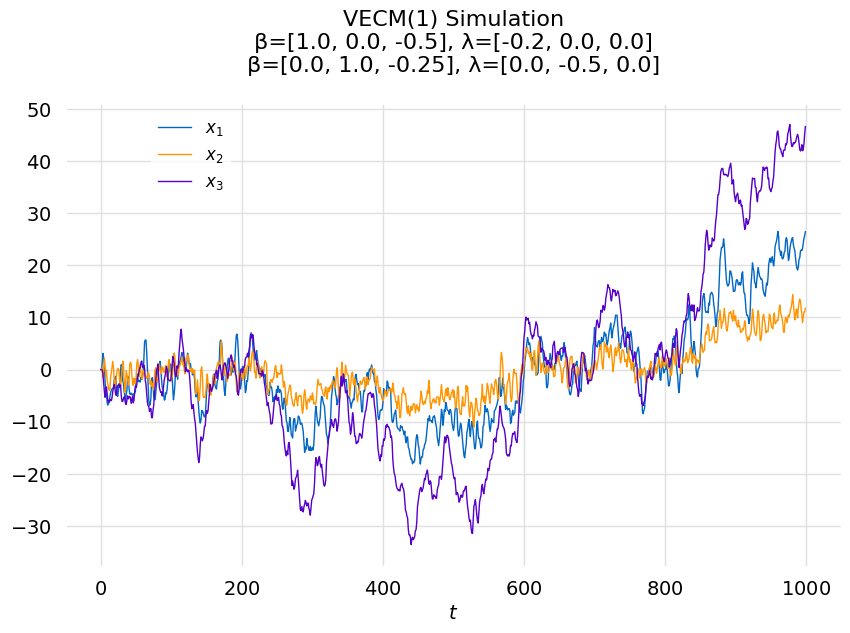

In [3]:
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.matrix([[0.5, 0.0, 0.0],
                  [0.0, 0.5, 0.0],
                  [0.0, 0.0, 0.5]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])

title = f"VECM(1) Simulation\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
t, xt = vecm.create_vecm1_source(λ, β, a, Ω=Ω)
plot_vecm_simulation(t, xt, title)

### Stationarity Test

In [4]:
adf_test(xt)

Not Stationary
Not Stationary
Not Stationary


In [5]:
dt, dxt = stats.compute_diff(t, xt)
adf_test(dxt)

Stationary
Stationary
Stationary


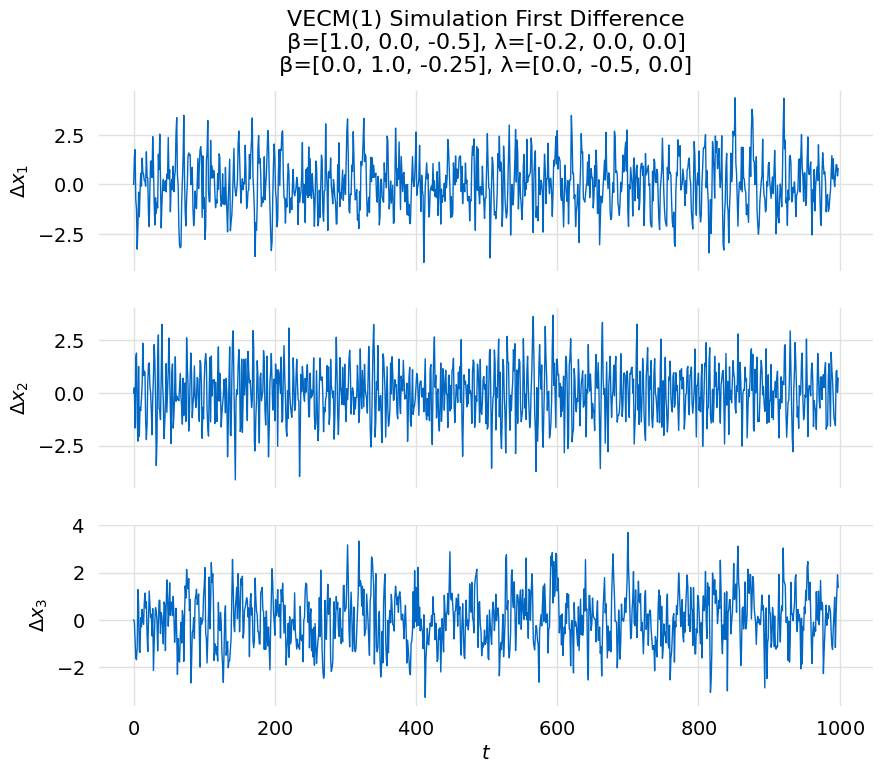

In [6]:
title = f"VECM(1) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
plot_vecm_dff(dxt, title)

### Order Determination

In [7]:
result, result_model = vecm.compute_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.9217,0.9956,2.514,0.9498
1,0.02886*,0.1471*,1.029*,0.07382*
2,0.03714,0.1997,1.038,0.09896
3,0.04713,0.2541,1.048,0.1258
4,0.05509,0.3064,1.057,0.1506


In [8]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "16a849a3-d713-41da-ac83-285259ba9194",
   "_VAROrderTestReport__order": {
      "test_id": "16a849a3-d713-41da-ac83-285259ba9194",
      "label": "$\\tau_{min}$",
      "value": 1
   },
   "_VAROrderTestReport__aic": {
      "test_id": "16a849a3-d713-41da-ac83-285259ba9194",
      "order": {
         "test_id": "16a849a3-d713-41da-ac83-285259ba9194",
         "label": "$\\tau_{AIC}$",
         "value": 1
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "16a849a3-d713-41da-ac83-285259ba9194",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.028858284219523044
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "16a849a3-d713-41da-ac83-285259ba9194",
      "order": {
         "test_id": "16a849a3-d713-41da-ac83-285259ba9194",
         "label": "$\\tau_{BIC}$",
         "value": 1
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "16a849a3-d713-41da-ac83-285259ba9194",
       

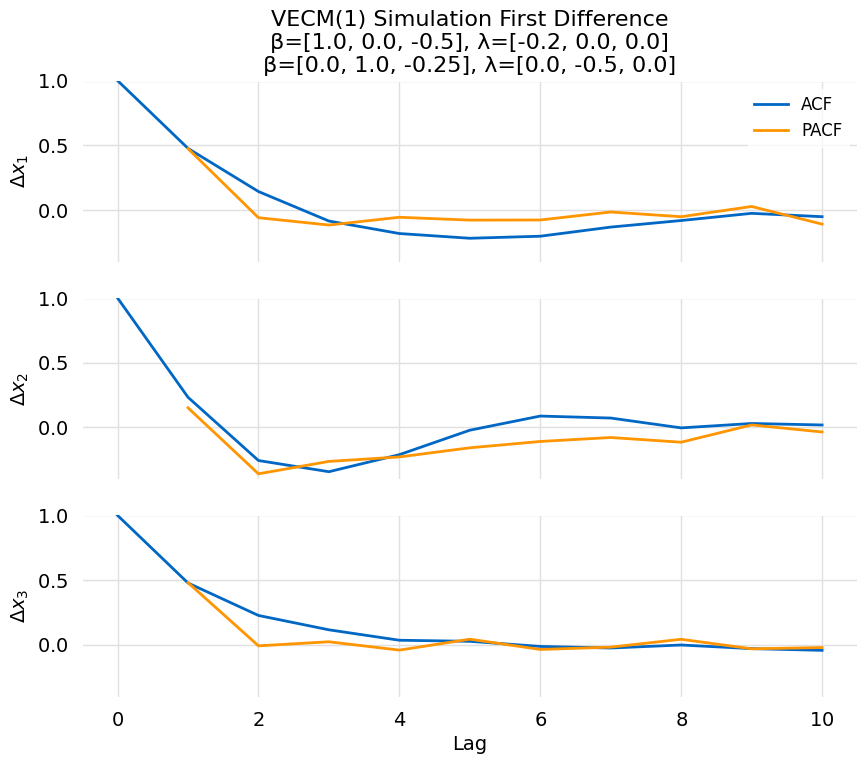

In [9]:
nlags = 10
title = f"VECM(1) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
pacf_acf_plot(dt, dxt, 10, title)

### $\Delta X_t$ Parameter Estimation

In [10]:
result, _ = arima.compute_ar_estimate(dxt[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1564.650
Date:                Sun, 03 Dec 2023   AIC                           3135.299
Time:                        14:48:28   BIC                           3150.020
Sample:                             0   HQIC                          3140.894
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0271      0.070      0.387      0.699      -0.110       0.165
ar.L1          0.4755      0.028     16.734      0.000       0.420       0.531
sigma2         1.3422      0.063     21.314      0.000       1.219       1.466
===================================================================================
Ljung-Box (L1) (Q):                   2.72   Jarque-Bera (JB):                 1.43
Prob(Q):                              0.10   Prob(JB):                         0.49
Heteroskedasticity (H):               0.93   Skew:                             0.05
Prob(H) (two-sided):                  0.48   Kurtosis:                         2.84
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [11]:
result, _ = arima.compute_ar_estimate(dxt[1], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1631.371
Date:                Sun, 03 Dec 2023   AIC                           3268.742
Time:                        14:48:29   BIC                           3283.462
Sample:                             0   HQIC                          3274.337
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0119      0.051      0.232      0.816      -0.089       0.112
ar.L1          0.2326      0.031      7.442      0.000       0.171       0.294
sigma2         1.5343      0.074     20.777      0.000       1.390       1.679
===================================================================================
Ljung-Box (L1) (Q):                   5.87   Jarque-Bera (JB):                 4.64
Prob(Q):                              0.02   Prob(JB):                         0.10
Heteroskedasticity (H):               0.82   Skew:                            -0.11
Prob(H) (two-sided):                  0.08   Kurtosis:                         2.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
result, _ = arima.compute_ar_estimate(dxt[2], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1400.875
Date:                Sun, 03 Dec 2023   AIC                           2807.750
Time:                        14:48:29   BIC                           2822.470
Sample:                             0   HQIC                          2813.345
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0478      0.060      0.802      0.422      -0.069       0.165
ar.L1          0.4776      0.029     16.537      0.000       0.421       0.534
sigma2         0.9670      0.043     22.265      0.000       0.882       1.052
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.37
Prob(Q):                              0.98   Prob(JB):                         0.83
Heteroskedasticity (H):               1.05   Skew:                            -0.05
Prob(H) (two-sided):                  0.64   Kurtosis:                         2.99
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Granger Causality

In [13]:
result, result_model = stats.compute_causality_matrix(dxt, nlags=1)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=996, df_num=1
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=1
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=1
parameter F test:         F=291.6273, p=0.0000  , df_denom=996, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.2255  , p=0.2686  , df_denom=995, df_num=1
ssr based chi2 test:   chi2=1.2292  , p=0.2676  , df=1
likelihood ratio test: chi2=1.2284  , p=0.2677  , df=1
parameter F test:         F=1.2255  , p=0.2686  , df_denom=995, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=17.3690 , p=0.0000  , df_denom=995, df_num=1
ssr based chi2 test:   chi2=17.4214 , p=0.0000  , df=1
likelihood ratio test: chi2=17.2710 , p=0.0000  , df=1
parameter F test:         F=17.3690 , p=0.0000  , df_denom=995, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.0962  , p=0.2954  

In [14]:
result.head(10)

,pvalue,critical_value,result,dependent_var,causal_var
1,1.0000,0.05,False,1,1
2,0.2686,0.05,False,1,2
3,0.0000,0.05,True,1,3
4,0.2954,0.05,False,2,1
5,1.0000,0.05,False,2,2
6,0.0000,0.05,True,2,3
7,0.6429,0.05,False,3,1
8,0.4061,0.05,False,3,2
9,1.0000,0.05,False,3,3


In [15]:
print(result_model.to_json(pretty=True))

{
   "test_id": "cf00dd3a-e8b1-43f9-9606-56fffdbbbe52",
   "rank": 2,
   "results": [
      {
         "_GrangerCausalityTestResult__est_id": "cf00dd3a-e8b1-43f9-9606-56fffdbbbe52",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 1,
         "_GrangerCausalityTestResult__pvalue": 1.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "cf00dd3a-e8b1-43f9-9606-56fffdbbbe52",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 2,
         "_GrangerCausalityTestResult__pvalue": 0.2686,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "cf00dd3a-e8b1-43f9-9606-56fffdbbbe52",
         "_GrangerCausalityTestResult__de

### Johansen Test for Cointegration

In [16]:
result, result_model, _ = vecm.compute_johansen_coint_test(xt, 1)

In [17]:
result.summary()

Trace Statistic
╒═══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│ Null Hypothesis   │   Test Statistic │   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞═══════════════════╪══════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ r <= 0            │          659.983 │               27.067 │               29.796 │               35.463 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 1            │          219.198 │               13.429 │               15.494 │               19.935 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 2            │            0.291 │                2.705 │                3.841 │                6.635 │
╘═══════════════════╧══════════════════╧══════════════════════╧══════════════════════╧══════════════════

In [18]:
print(result_model.to_json(pretty=True))

{
   "test_id": "3d8fb9fe-6680-4b94-a8a6-4e07abc2fed4",
   "trace_test": [
      {
         "test_id": "3d8fb9fe-6680-4b94-a8a6-4e07abc2fed4",
         "test_rank": 0,
         "null_hypothesis": "r<=0",
         "test_stat": 659.9832401320499,
         "critical_values": [
            27.0669,
            29.7961,
            35.4628
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 99%"
         ],
         "test_result": [
            true,
            true,
            true
         ]
      },
      {
         "test_id": "3d8fb9fe-6680-4b94-a8a6-4e07abc2fed4",
         "test_rank": 1,
         "null_hypothesis": "r<=1",
         "test_stat": 219.19803297247748,
         "critical_values": [
            13.4294,
            15.4943,
            19.9349
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 

### VECM Parameter Estimation

```
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.matrix([[0.5, 0.0, 0.0],
                  [0.0, 0.5, 0.0],
                  [0.0, 0.0, 0.5]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])
```

In [19]:
result, result_model = vecm.compute_estimate(xt, maxlags=1, rank=2)
result.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0062,0.033,-0.191,0.848,-0.070,0.058
L1.y1,0.5422,0.025,21.354,0.000,0.492,0.592
L1.y2,0.0160,0.028,0.573,0.566,-0.039,0.071
L1.y3,-0.0122,0.032,-0.384,0.701,-0.074,0.050
,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0121,0.031,-0.388,0.698,-0.073,0.049
L1.y1,0.0080,0.024,0.330,0.741,-0.040,0.056
L1.y2,0.4772,0.027,17.779,0.000,0.425,0.530
L1.y3,-0.0505,0.030,-1.666,0.096,-0.110,0.009
,coef,std err,z,P>|z|,[0.025,0.975]


In [20]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VECM",
   "rank": 2,
   "const": [
      {
         "est": -0.006232805192596367,
         "err": 0.03257928193746177,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "9dfeb1cb-a90f-4c63-830e-19c0d66e5ca0",
         "param_type": "VECM_CONST"
      },
      {
         "est": -0.012128706495532458,
         "err": 0.03125596449097588,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "9dfeb1cb-a90f-4c63-830e-19c0d66e5ca0",
         "param_type": "VECM_CONST"
      },
      {
         "est": 0.026307710679320424,
         "err": 0.031130465667471477,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 2,
         "column": 0,
         "order": 0,
         "est_id": "9dfeb1cb-a90f-4c63-830e-19c0d66e5ca0",
         "param_

### Verify Error Correction term Residual Stationarity

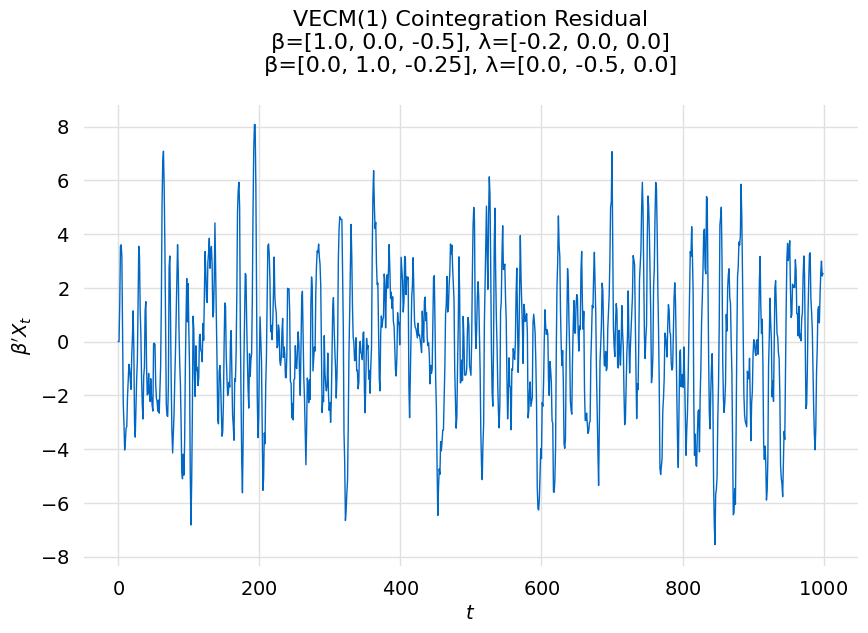

In [21]:
beta_est = result.beta
coint = beta_est.T[0] * xt.T / beta_est.T[0][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(1) Cointegration Residual\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [22]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -14.6847      │
├────────────────┼───────────────┤
│ pvalue         │   2.98316e-26 │
├────────────────┼───────────────┤
│ Lags           │   2           │
├────────────────┼───────────────┤
│ Number Obs     │ 997           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


## VECM(2) Two Cointegrating Vectors

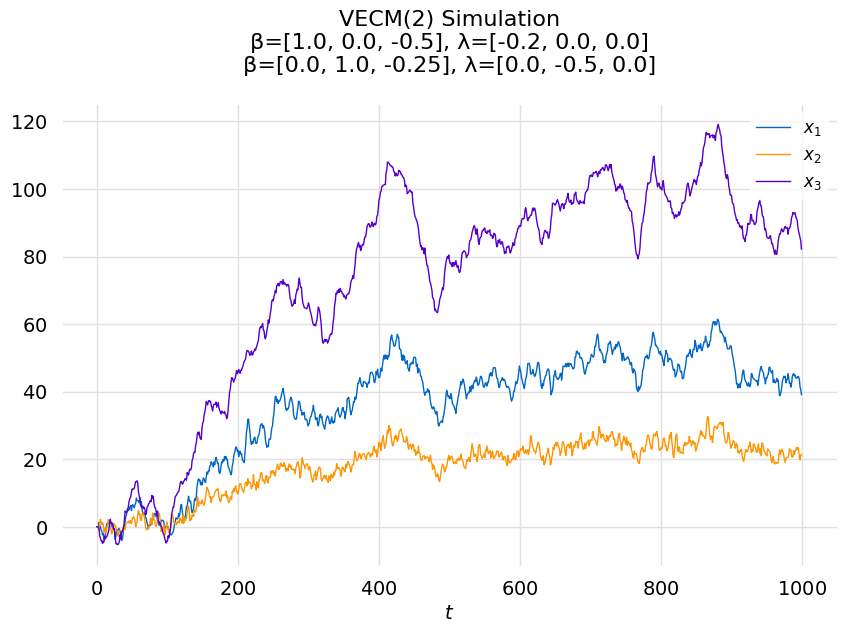

In [23]:
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])

title = f"VECM(2) Simulation\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
t, xt = vecm.create_vecm_source(λ, β, a, Ω=Ω)
plot_vecm_simulation(t, xt, title)

### Stationarity Test

In [24]:
adf_test(xt)

Not Stationary
Not Stationary
Not Stationary


In [25]:
dt, dxt = stats.compute_diff(t, xt)
adf_test(dxt)

Stationary
Stationary
Stationary


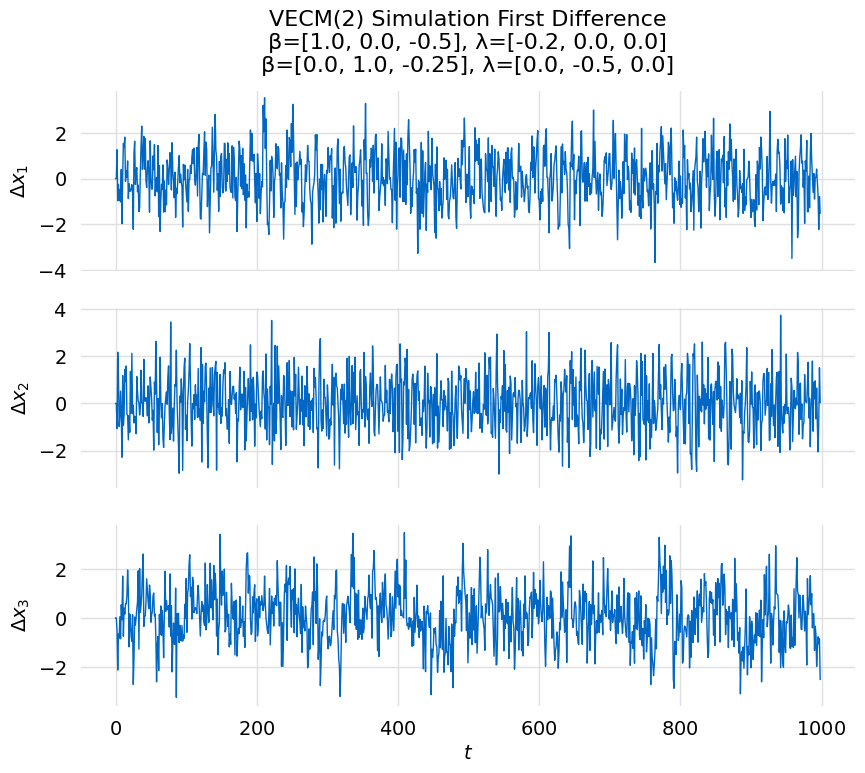

In [26]:
title = f"VECM(2) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
plot_vecm_dff(dxt, title)

### Order Determination

In [27]:
result, result_model = vecm.compute_order(xt, maxlags=6)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.3838,0.4579,1.468,0.4120
1,0.1599,0.2784,1.173,0.2050
2,0.02299*,0.1859*,1.023*,0.08491*
3,0.02658,0.2339,1.027,0.1054
4,0.04142,0.2931,1.042,0.1371
5,0.04897,0.3451,1.050,0.1616
6,0.06334,0.4039,1.065,0.1928


In [28]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "7e59de96-0e24-4da5-8d86-d612cb00b561",
   "_VAROrderTestReport__order": {
      "test_id": "7e59de96-0e24-4da5-8d86-d612cb00b561",
      "label": "$\\tau_{min}$",
      "value": 2
   },
   "_VAROrderTestReport__aic": {
      "test_id": "7e59de96-0e24-4da5-8d86-d612cb00b561",
      "order": {
         "test_id": "7e59de96-0e24-4da5-8d86-d612cb00b561",
         "label": "$\\tau_{AIC}$",
         "value": 2
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "7e59de96-0e24-4da5-8d86-d612cb00b561",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.022992849837688976
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "7e59de96-0e24-4da5-8d86-d612cb00b561",
      "order": {
         "test_id": "7e59de96-0e24-4da5-8d86-d612cb00b561",
         "label": "$\\tau_{BIC}$",
         "value": 2
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "7e59de96-0e24-4da5-8d86-d612cb00b561",
       

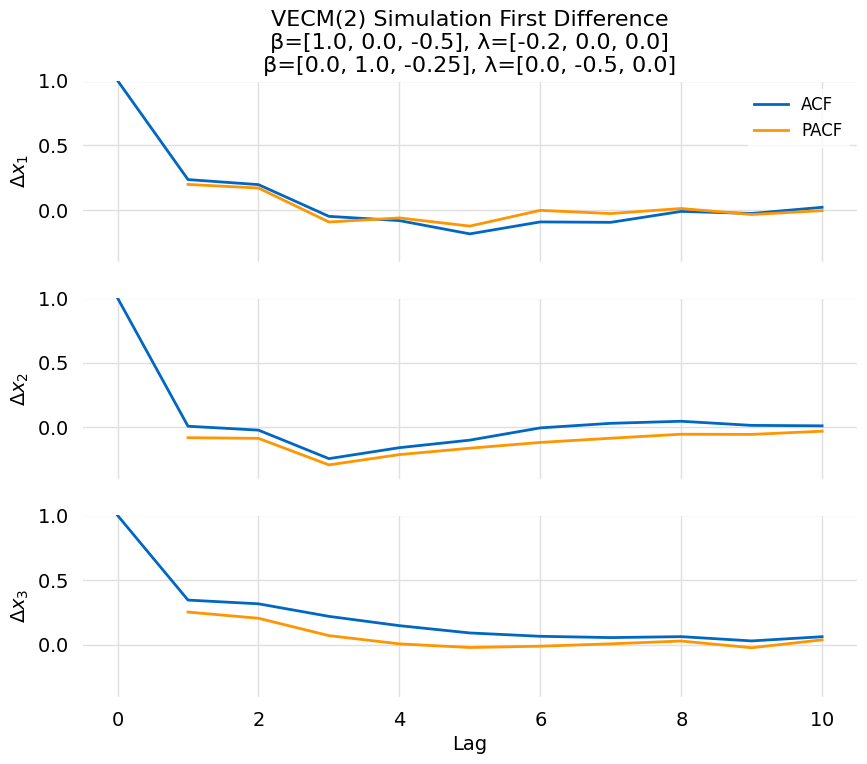

In [29]:
nlags = 10
title = f"VECM(2) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
pacf_acf_plot(dt, dxt, 10, title)

### $\Delta X_t$ Parameter Estimation

In [30]:
result, _ = arima.compute_ar_estimate(dxt[0], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1502.929
Date:                Sun, 03 Dec 2023   AIC                           3013.858
Time:                        14:48:32   BIC                           3033.485
Sample:                             0   HQIC                          3021.318
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0381      0.053      0.719      0.472      -0.066       0.142
ar.L1          0.2001      0.033      6.054      0.000       0.135       0.265
ar.L2          0.1491      0.032      4.707      0.000       0.087       0.211
sigma2         1.1863      0.057     20.825      0.000       1.075       1.298
===================================================================================
Ljung-Box (L1) (Q):                   0.40   Jarque-Bera (JB):                 3.01
Prob(Q):                              0.53   Prob(JB):                         0.22
Heteroskedasticity (H):               1.04   Skew:                            -0.06
Prob(H) (two-sided):                  0.75   Kurtosis:                         2.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [31]:
result, _ = arima.compute_ar_estimate(dxt[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1570.208
Date:                Sun, 03 Dec 2023   AIC                           3148.416
Time:                        14:48:32   BIC                           3168.043
Sample:                             0   HQIC                          3155.876
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0213      0.036      0.585      0.558      -0.050       0.093
ar.L1          0.0090      0.031      0.295      0.768      -0.051       0.069
ar.L2         -0.0213      0.033     -0.650      0.516      -0.086       0.043
sigma2         1.3575      0.063     21.478      0.000       1.234       1.481
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 0.91
Prob(Q):                              0.87   Prob(JB):                         0.63
Heteroskedasticity (H):               1.12   Skew:                             0.03
Prob(H) (two-sided):                  0.30   Kurtosis:                         2.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [32]:
result, _ = arima.compute_ar_estimate(dxt[2], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1437.334
Date:                Sun, 03 Dec 2023   AIC                           2882.669
Time:                        14:48:32   BIC                           2902.296
Sample:                             0   HQIC                          2890.129
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0792      0.064      1.240      0.215      -0.046       0.204
ar.L1          0.2692      0.032      8.327      0.000       0.206       0.333
ar.L2          0.2250      0.031      7.156      0.000       0.163       0.287
sigma2         1.0402      0.044     23.902      0.000       0.955       1.126
===================================================================================
Ljung-Box (L1) (Q):                   0.23   Jarque-Bera (JB):                 3.47
Prob(Q):                              0.63   Prob(JB):                         0.18
Heteroskedasticity (H):               1.08   Skew:                             0.01
Prob(H) (two-sided):                  0.49   Kurtosis:                         3.29
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Granger Causality

In [33]:
result, result_model = stats.compute_causality_matrix(dxt, nlags=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=996, df_num=1
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=1
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=1
parameter F test:         F=58.2438 , p=0.0000  , df_denom=996, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=994, df_num=2
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=2
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=2
parameter F test:         F=41.0526 , p=0.0000  , df_denom=994, df_num=2

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.1631  , p=0.2811  , df_denom=995, df_num=1
ssr based chi2 test:   chi2=1.1666  , p=0.2801  , df=1
likelihood ratio test: chi2=1.1659  , p=0.2802  , df=1
parameter F test:         F=1.1631  , p=0.2811  , df_denom=995, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.8891  , p=0.0561  

In [34]:
result.head(10)

,pvalue,critical_value,result,dependent_var,causal_var
1,1.0000,0.05,False,1,1
2,0.0561,0.05,False,1,2
3,0.0000,0.05,True,1,3
4,0.7359,0.05,False,2,1
5,1.0000,0.05,False,2,2
6,0.0000,0.05,True,2,3
7,0.1198,0.05,False,3,1
8,0.0239,0.05,True,3,2
9,1.0000,0.05,False,3,3


In [35]:
print(result_model.to_json(pretty=True))

{
   "test_id": "453b8315-7573-4136-8396-9bdbd40d1a61",
   "rank": 3,
   "results": [
      {
         "_GrangerCausalityTestResult__est_id": "453b8315-7573-4136-8396-9bdbd40d1a61",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 1,
         "_GrangerCausalityTestResult__pvalue": 1.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "453b8315-7573-4136-8396-9bdbd40d1a61",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 2,
         "_GrangerCausalityTestResult__pvalue": 0.0561,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "453b8315-7573-4136-8396-9bdbd40d1a61",
         "_GrangerCausalityTestResult__de

### Johansen Test for Cointegration

In [36]:
result, result_model, _ = vecm.compute_johansen_coint_test(xt, 2)

In [37]:
result.summary()

Trace Statistic
╒═══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│ Null Hypothesis   │   Test Statistic │   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞═══════════════════╪══════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ r <= 0            │          472.354 │               27.067 │               29.796 │               35.463 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 1            │          160.072 │               13.429 │               15.494 │               19.935 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 2            │            4.893 │                2.705 │                3.841 │                6.635 │
╘═══════════════════╧══════════════════╧══════════════════════╧══════════════════════╧══════════════════

In [38]:
print(result_model.to_json(pretty=True))

{
   "test_id": "65e81abe-aea1-4810-a37f-7bce847a82b5",
   "trace_test": [
      {
         "test_id": "65e81abe-aea1-4810-a37f-7bce847a82b5",
         "test_rank": 0,
         "null_hypothesis": "r<=0",
         "test_stat": 472.35390597652776,
         "critical_values": [
            27.0669,
            29.7961,
            35.4628
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 99%"
         ],
         "test_result": [
            true,
            true,
            true
         ]
      },
      {
         "test_id": "65e81abe-aea1-4810-a37f-7bce847a82b5",
         "test_rank": 1,
         "null_hypothesis": "r<=1",
         "test_stat": 160.07157164254184,
         "critical_values": [
            13.4294,
            15.4943,
            19.9349
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value

### VECM Parameter Estimation

```
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])
```



In [39]:
result, result_model = vecm.compute_estimate(xt, maxlags=2, rank=2)
result.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
const,0.0161,0.031,0.516,0.606,-0.045,0.077
L1.y1,0.2213,0.029,7.613,0.000,0.164,0.278
L1.y2,-0.0262,0.031,-0.854,0.393,-0.086,0.034
L1.y3,0.0254,0.032,0.787,0.431,-0.038,0.089
L2.y1,0.2244,0.029,7.710,0.000,0.167,0.281
L2.y2,0.0035,0.030,0.116,0.907,-0.056,0.063
L2.y3,0.0109,0.033,0.334,0.738,-0.053,0.075
,coef,std err,z,P>|z|,[0.025,0.975]
const,0.0372,0.031,1.185,0.236,-0.024,0.099
L1.y1,-0.0436,0.029,-1.494,0.135,-0.101,0.014


In [40]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VECM",
   "rank": 2,
   "const": [
      {
         "est": 0.016136819318407724,
         "err": 0.03127218524741489,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "e3bfa434-88e7-46a6-acc8-fd32b003acc8",
         "param_type": "VECM_CONST"
      },
      {
         "est": 0.03715687038379836,
         "err": 0.03136799406181188,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "e3bfa434-88e7-46a6-acc8-fd32b003acc8",
         "param_type": "VECM_CONST"
      },
      {
         "est": 0.04050090005858849,
         "err": 0.03252870163207463,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 2,
         "column": 0,
         "order": 0,
         "est_id": "e3bfa434-88e7-46a6-acc8-fd32b003acc8",
         "param_type"

### Verify Error Correction term Residual Stationarity

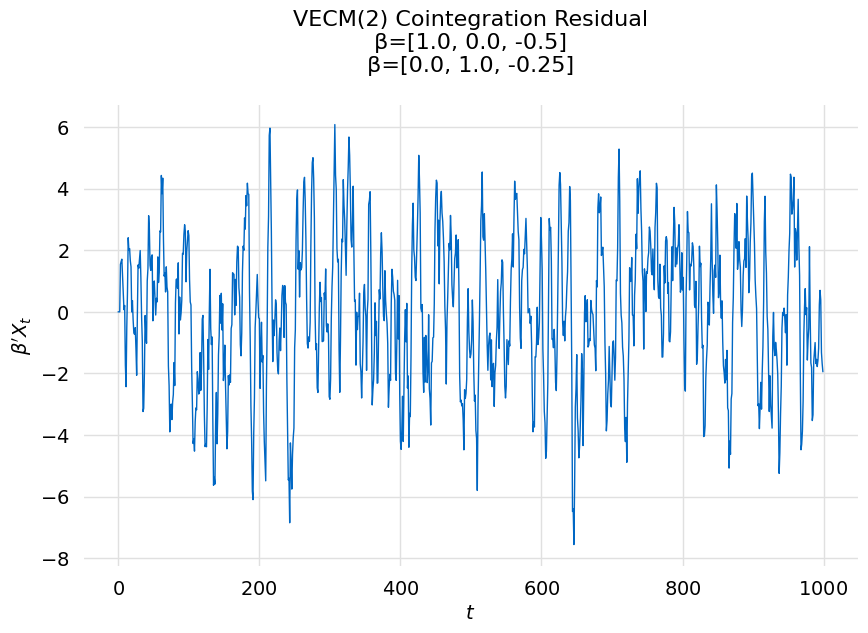

In [41]:
beta_est = result.beta
coint = beta_est.T[0] * xt.T / beta_est.T[0][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(2) Cointegration Residual\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [42]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -12.2129      │
├────────────────┼───────────────┤
│ pvalue         │   2.82335e-22 │
├────────────────┼───────────────┤
│ Lags           │   2           │
├────────────────┼───────────────┤
│ Number Obs     │ 997           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


## VECM(3) Two Cointegrating Vectors

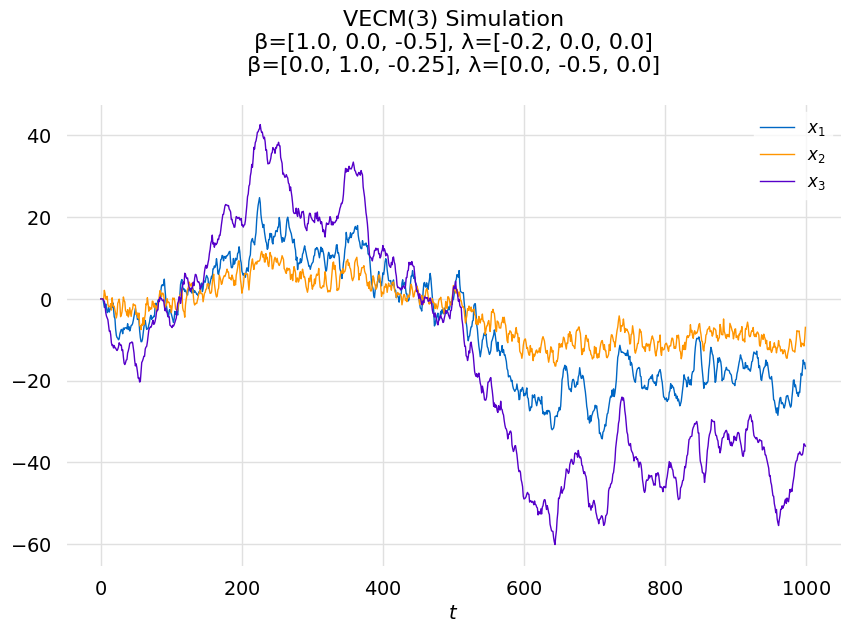

In [43]:
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.1, 0.0, 0.0],
                  [0.0, 0.1, 0.0],
                  [0.0, 0.0, 0.1]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])

title = f"VECM(3) Simulation\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
t, xt = vecm.create_vecm_source(λ, β, a, Ω=Ω)
plot_vecm_simulation(t, xt, title)

### Stationarity Test

In [44]:
adf_test(xt)

Not Stationary
Not Stationary
Not Stationary


In [45]:
dt, dxt = stats.compute_diff(t, xt)
adf_test(dxt)

Stationary
Stationary
Stationary


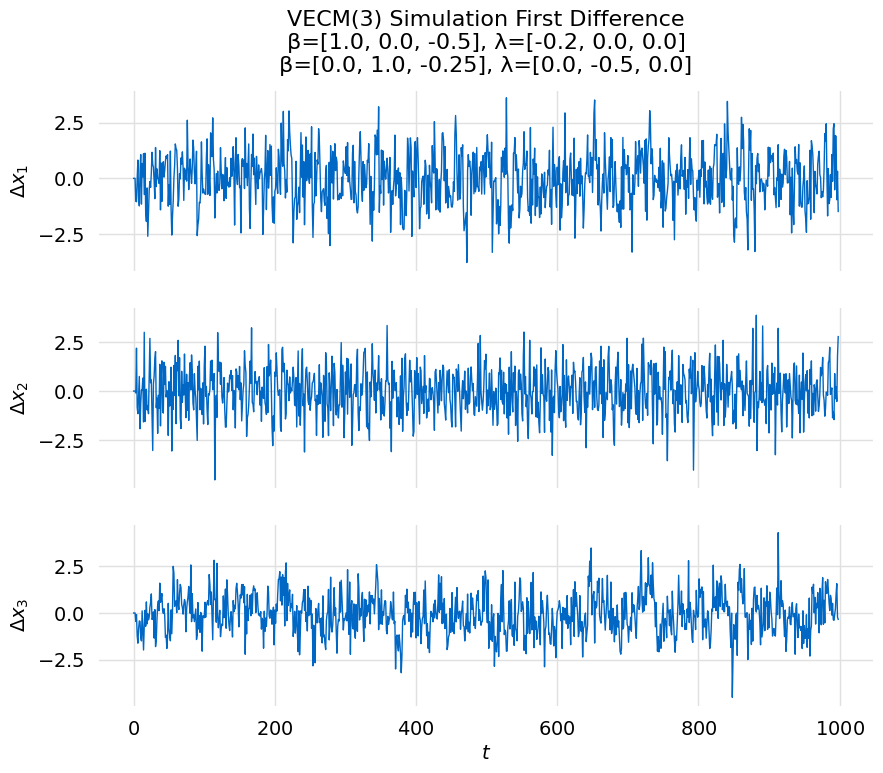

In [46]:
title = f"VECM(3) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
plot_vecm_dff(dxt, title)

### Order Determination

In [47]:
result, result_model = vecm.compute_order(xt, maxlags=6)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.5599,0.6339,1.750,0.5880
1,0.3200,0.4384,1.377,0.3650
2,0.1321,0.2949*,1.141,0.1940
3,0.1025*,0.3098,1.108*,0.1813*
4,0.1163,0.3680,1.123,0.2120
5,0.1219,0.4181,1.130,0.2345
6,0.1358,0.4763,1.145,0.2653


In [48]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "714c5a0e-edd9-48a0-8159-47991610c89e",
   "_VAROrderTestReport__order": {
      "test_id": "714c5a0e-edd9-48a0-8159-47991610c89e",
      "label": "$\\tau_{min}$",
      "value": 3
   },
   "_VAROrderTestReport__aic": {
      "test_id": "714c5a0e-edd9-48a0-8159-47991610c89e",
      "order": {
         "test_id": "714c5a0e-edd9-48a0-8159-47991610c89e",
         "label": "$\\tau_{AIC}$",
         "value": 3
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "714c5a0e-edd9-48a0-8159-47991610c89e",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.10247719367758279
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "714c5a0e-edd9-48a0-8159-47991610c89e",
      "order": {
         "test_id": "714c5a0e-edd9-48a0-8159-47991610c89e",
         "label": "$\\tau_{BIC}$",
         "value": 3
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "714c5a0e-edd9-48a0-8159-47991610c89e",
        

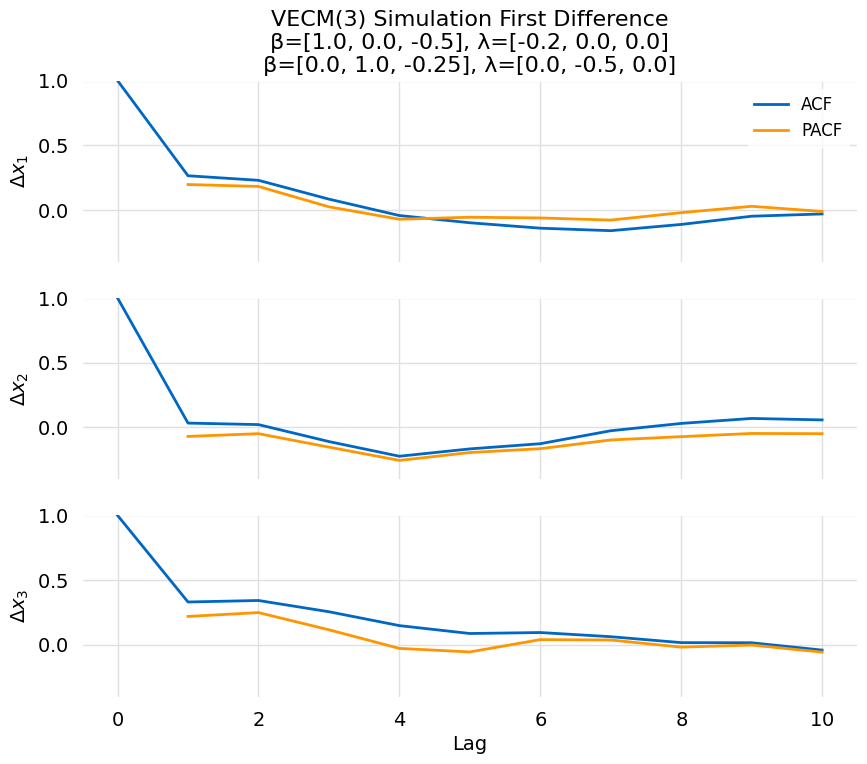

In [49]:
nlags = 10
title = f"VECM(3) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
pacf_acf_plot(dt, dxt, 10, title)

### $\Delta X_t$ Parameter Estimation

In [50]:
result, _ = arima.compute_ar_estimate(dxt[0], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1529.703
Date:                Sun, 03 Dec 2023   AIC                           3069.406
Time:                        14:48:35   BIC                           3093.940
Sample:                             0   HQIC                          3078.731
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0179      0.057     -0.311      0.755      -0.130       0.095
ar.L1          0.2214      0.031      7.229      0.000       0.161       0.281
ar.L2          0.1739      0.032      5.518      0.000       0.112       0.236
ar.L3         -0.0130      0.034     -0.388      0.698      -0.079       0.053
sigma2         1.2516      0.056     22.178      0.000       1.141       1.362
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.44
Prob(Q):                              0.97   Prob(JB):                         0.80
Heteroskedasticity (H):               1.06   Skew:                            -0.05
Prob(H) (two-sided):                  0.59   Kurtosis:                         2.97
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [51]:
result, _ = arima.compute_ar_estimate(dxt[1], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1591.290
Date:                Sun, 03 Dec 2023   AIC                           3192.580
Time:                        14:48:35   BIC                           3217.114
Sample:                             0   HQIC                          3201.905
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0072      0.036     -0.200      0.841      -0.078       0.063
ar.L1          0.0352      0.032      1.112      0.266      -0.027       0.097
ar.L2          0.0240      0.033      0.718      0.473      -0.041       0.089
ar.L3         -0.1116      0.034     -3.282      0.001      -0.178      -0.045
sigma2         1.4160      0.062     22.708      0.000       1.294       1.538
===================================================================================
Ljung-Box (L1) (Q):                   0.60   Jarque-Bera (JB):                 0.64
Prob(Q):                              0.44   Prob(JB):                         0.72
Heteroskedasticity (H):               0.99   Skew:                            -0.04
Prob(H) (two-sided):                  0.90   Kurtosis:                         3.09
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [52]:
result, _ = arima.compute_ar_estimate(dxt[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1400.360
Date:                Sun, 03 Dec 2023   AIC                           2810.720
Time:                        14:48:35   BIC                           2835.253
Sample:                             0   HQIC                          2820.045
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0361      0.070     -0.512      0.608      -0.174       0.102
ar.L1          0.2170      0.032      6.793      0.000       0.154       0.280
ar.L2          0.2360      0.032      7.375      0.000       0.173       0.299
ar.L3          0.1027      0.033      3.096      0.002       0.038       0.168
sigma2         0.9659      0.040     24.015      0.000       0.887       1.045
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 8.92
Prob(Q):                              0.92   Prob(JB):                         0.01
Heteroskedasticity (H):               1.15   Skew:                             0.14
Prob(H) (two-sided):                  0.22   Kurtosis:                         3.37
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Granger Causality

In [53]:
result, result_model = stats.compute_causality_matrix(dxt, nlags=3)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=-0.0000 , p=1.0000  , df_denom=996, df_num=1
ssr based chi2 test:   chi2=-0.0000 , p=1.0000  , df=1
likelihood ratio test: chi2=0.0000  , p=1.0000  , df=1
parameter F test:         F=74.9958 , p=0.0000  , df_denom=996, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=994, df_num=2
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=2
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=2
parameter F test:         F=53.5556 , p=0.0000  , df_denom=994, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=992, df_num=3
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=3
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=3
parameter F test:         F=35.6942 , p=0.0000  , df_denom=992, df_num=3

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=2.5463  , p=0.1109  

In [54]:
result.head(10)

,pvalue,critical_value,result,dependent_var,causal_var
1,1.0000,0.05,False,1,1
2,0.1109,0.05,False,1,2
3,0.0000,0.05,True,1,3
4,0.2637,0.05,False,2,1
5,1.0000,0.05,False,2,2
6,0.0000,0.05,True,2,3
7,0.0060,0.05,True,3,1
8,0.2908,0.05,False,3,2
9,1.0000,0.05,False,3,3


In [55]:
print(result_model.to_json(pretty=True))

{
   "test_id": "645f00ae-6c72-48a4-aaf6-427afc75b0c0",
   "rank": 3,
   "results": [
      {
         "_GrangerCausalityTestResult__est_id": "645f00ae-6c72-48a4-aaf6-427afc75b0c0",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 1,
         "_GrangerCausalityTestResult__pvalue": 1.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "645f00ae-6c72-48a4-aaf6-427afc75b0c0",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 2,
         "_GrangerCausalityTestResult__pvalue": 0.1109,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "645f00ae-6c72-48a4-aaf6-427afc75b0c0",
         "_GrangerCausalityTestResult__de

### Johansen Test for Cointegration

In [56]:
result, result_model, _ = vecm.compute_johansen_coint_test(xt, 3)

In [57]:
result.summary()

Trace Statistic
╒═══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│ Null Hypothesis   │   Test Statistic │   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞═══════════════════╪══════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ r <= 0            │          431.406 │               27.067 │               29.796 │               35.463 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 1            │          144.140 │               13.429 │               15.494 │               19.935 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 2            │            1.482 │                2.705 │                3.841 │                6.635 │
╘═══════════════════╧══════════════════╧══════════════════════╧══════════════════════╧══════════════════

In [58]:
print(result_model.to_json(pretty=True))

{
   "test_id": "2b35a5e7-aefd-4167-84db-dd8c41815028",
   "trace_test": [
      {
         "test_id": "2b35a5e7-aefd-4167-84db-dd8c41815028",
         "test_rank": 0,
         "null_hypothesis": "r<=0",
         "test_stat": 431.4056084354502,
         "critical_values": [
            27.0669,
            29.7961,
            35.4628
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 99%"
         ],
         "test_result": [
            true,
            true,
            true
         ]
      },
      {
         "test_id": "2b35a5e7-aefd-4167-84db-dd8c41815028",
         "test_rank": 1,
         "null_hypothesis": "r<=1",
         "test_stat": 144.13968689320302,
         "critical_values": [
            13.4294,
            15.4943,
            19.9349
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 

### VECM Parameter Estimation

```
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.1, 0.0, 0.0],
                  [0.0, 0.1, 0.0],
                  [0.0, 0.0, 0.1]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])
```



In [63]:
result, result_model = vecm.compute_estimate(xt, maxlags=3, rank=2)
result.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0148,0.032,-0.459,0.647,-0.078,0.048
L1.y1,0.2232,0.030,7.553,0.000,0.165,0.281
L1.y2,-0.0038,0.031,-0.123,0.902,-0.065,0.057
L1.y3,-0.0448,0.034,-1.315,0.188,-0.112,0.022
L2.y1,0.2286,0.030,7.626,0.000,0.170,0.287
L2.y2,-0.0246,0.031,-0.800,0.424,-0.085,0.036
L2.y3,0.0388,0.034,1.134,0.257,-0.028,0.106
L3.y1,0.0903,0.031,2.957,0.003,0.030,0.150
L3.y2,-0.0032,0.031,-0.103,0.918,-0.064,0.057
L3.y3,0.0498,0.035,1.432,0.152,-0.018,0.118


In [60]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VECM",
   "rank": 1,
   "const": [
      {
         "est": -0.000957968107819168,
         "err": 0.03458841638603468,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "0c1c59c3-d748-43aa-8dce-0b050e65b9ac",
         "param_type": "VECM_CONST"
      },
      {
         "est": 0.011078220662911444,
         "err": 0.032196540113403116,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "0c1c59c3-d748-43aa-8dce-0b050e65b9ac",
         "param_type": "VECM_CONST"
      },
      {
         "est": -0.016769180465901975,
         "err": 0.031085201318188354,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 2,
         "column": 0,
         "order": 0,
         "est_id": "0c1c59c3-d748-43aa-8dce-0b050e65b9ac",
         "param

### Verify Error Correction term Residual Stationarity

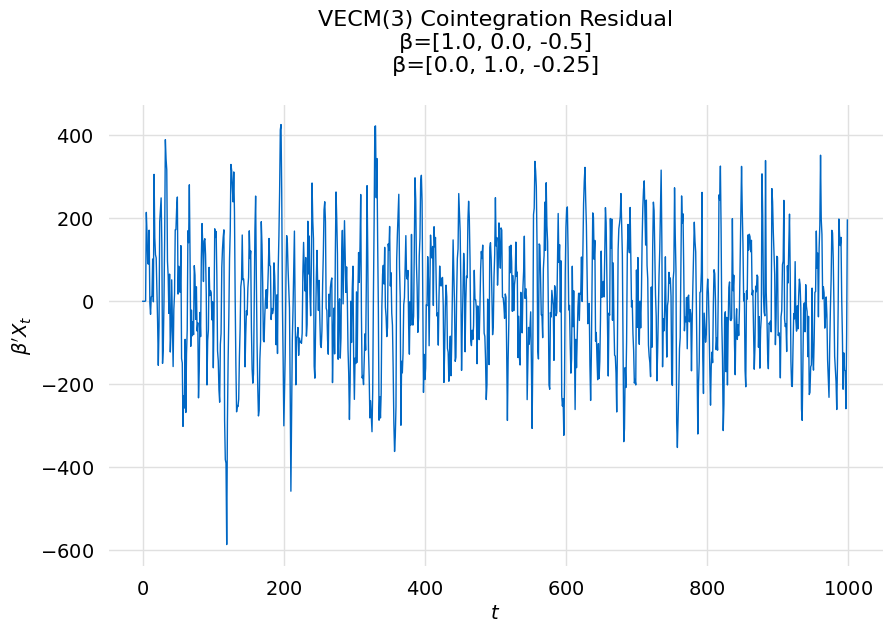

In [61]:
beta_est = result.beta
coint = beta_est.T[0] * xt.T / beta_est.T[0][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(3) Cointegration Residual\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [62]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -18.1878      │
├────────────────┼───────────────┤
│ pvalue         │   4.53685e-29 │
├────────────────┼───────────────┤
│ Lags           │   3           │
├────────────────┼───────────────┤
│ Number Obs     │ 996           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛
